# Applied Machine Learning — Assignment 1
### GPU Kernel Performance Analysis
**Name:** Shreya  
**Dataset:** SGEMM GPU Kernel Performance (UCI ML Repository)  
**Objective:** Implement Linear Regression and Logistic Regression using Gradient Descent to predict GPU computation time.

---
## Table of Contents
1. [Introduction](#introduction)
2. [Dataset Description](#dataset)
3. [Data Preprocessing](#preprocessing)
4. [Algorithms](#algorithms)
5. [Experiments](#experiments)
6. [Conclusion](#conclusion)

---
## 1. Introduction <a id='introduction'></a>

In this assignment, we implement **Linear Regression** and **Logistic Regression** from scratch using the **Gradient Descent** algorithm with batch update on the GPU Kernel Performance dataset.

The goal is to:
- **Linear Regression**: Predict the average GPU computation time (continuous target)
- **Logistic Regression**: Classify whether the GPU runtime is above or below average (binary target)

We experiment with different learning rates and convergence thresholds to find the optimal model parameters.

---
## 2. Dataset Description <a id='dataset'></a>

In [82]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [57]:
# Load the dataset
df = pd.read_csv('assign.csv')
print("Dataset Shape:", df.shape)
print("Column Names:")
print(list(df.columns))
print("First 5 rows:")
df.head()

Dataset Shape: (241600, 18)
Column Names:
['MWG', 'NWG', 'KWG', 'MDIMC', 'NDIMC', 'MDIMA', 'NDIMB', 'KWI', 'VWM', 'VWN', 'STRM', 'STRN', 'SA', 'SB', 'Run1 (ms)', 'Run2 (ms)', 'Run3 (ms)', 'Run4 (ms)']
First 5 rows:


,MWG,NWG,KWG,MDIMC,NDIMC,MDIMA,NDIMB,KWI,VWM,VWN,STRM,STRN,SA,SB,Run1 (ms),Run2 (ms),Run3 (ms),Run4 (ms)
0,16,16,16,8,8,8,8,2,1,1,0,0,0,0,115.26,115.87,118.55,115.80
1,16,16,16,8,8,8,8,2,1,1,0,0,0,1,78.13,78.25,79.25,79.19
2,16,16,16,8,8,8,8,2,1,1,0,0,1,0,79.84,80.69,80.76,80.97
3,16,16,16,8,8,8,8,2,1,1,0,0,1,1,84.32,89.90,86.75,85.58
4,16,16,16,8,8,8,8,2,1,1,0,1,0,0,115.13,121.98,122.73,114.81


In [58]:
# Basic dataset information
print("Dataset Info:")
print("Total Rows:")
print(df.shape[0])
print("Total Columns:")
print(df.shape[1])
print('summary:')
print(df.describe)
print("Data Types:")
print(df.dtypes)

Dataset Info:
Total Rows:
241600
Total Columns:
18
summary:
<bound method NDFrame.describe of         MWG  NWG  KWG  MDIMC  NDIMC  MDIMA  NDIMB  KWI  VWM  VWN  STRM  STRN  \
0        16   16   16      8      8      8      8    2    1    1     0     0   
1        16   16   16      8      8      8      8    2    1    1     0     0   
2        16   16   16      8      8      8      8    2    1    1     0     0   
3        16   16   16      8      8      8      8    2    1    1     0     0   
4        16   16   16      8      8      8      8    2    1    1     0     1   
...     ...  ...  ...    ...    ...    ...    ...  ...  ...  ...   ...   ...   
241595  128  128   32     32     32     32     32    8    4    4     1     0   
241596  128  128   32     32     32     32     32    8    4    4     1     1   
241597  128  128   32     32     32     32     32    8    4    4     1     1   
241598  128  128   32     32     32     32     32    8    4    4     1     1   
241599  128  128   32     

---
## 3. Data Preprocessing <a id='preprocessing'></a>

We follow these preprocessing steps:
1. Create a single average runtime target variable
2. Check for null values
3. Remove outliers using IQR
4. Check target variable distribution (apply log transformation if skewed)
5. Feature scaling (Z-score normalization)
6. Correlation matrix
7. Add intercept column

In [59]:
# Step 1: Create average runtime target variable
df['avg_runtime'] = df[['Run1 (ms)', 'Run2 (ms)', 'Run3 (ms)', 'Run4 (ms)']].mean(axis=1)
print("Average Runtime Statistics:")
print(df['avg_runtime'].describe())

Average Runtime Statistics:
count    241600.000000
mean        217.571953
std         368.750161
min          13.317500
25%          40.667500
50%          69.790000
75%         228.387500
max        3341.507500
Name: avg_runtime, dtype: float64


In [60]:
# Step 2: Check for null values
print("Null Values in each column:")
print(df.isnull().sum())
print("Total null values:")
print(df.isnull().sum().sum())
print("Conclusion: The dataset has NO null values.")

Null Values in each column:
MWG            0
NWG            0
KWG            0
MDIMC          0
NDIMC          0
MDIMA          0
NDIMB          0
KWI            0
VWM            0
VWN            0
STRM           0
STRN           0
SA             0
SB             0
Run1 (ms)      0
Run2 (ms)      0
Run3 (ms)      0
Run4 (ms)      0
avg_runtime    0
dtype: int64
Total null values:
0
Conclusion: The dataset has NO null values.


Q1: 40.6675
Q3: 228.3875
IQR: 187.7200
Lower Bound: -240.9125
Upper Bound: 509.9675


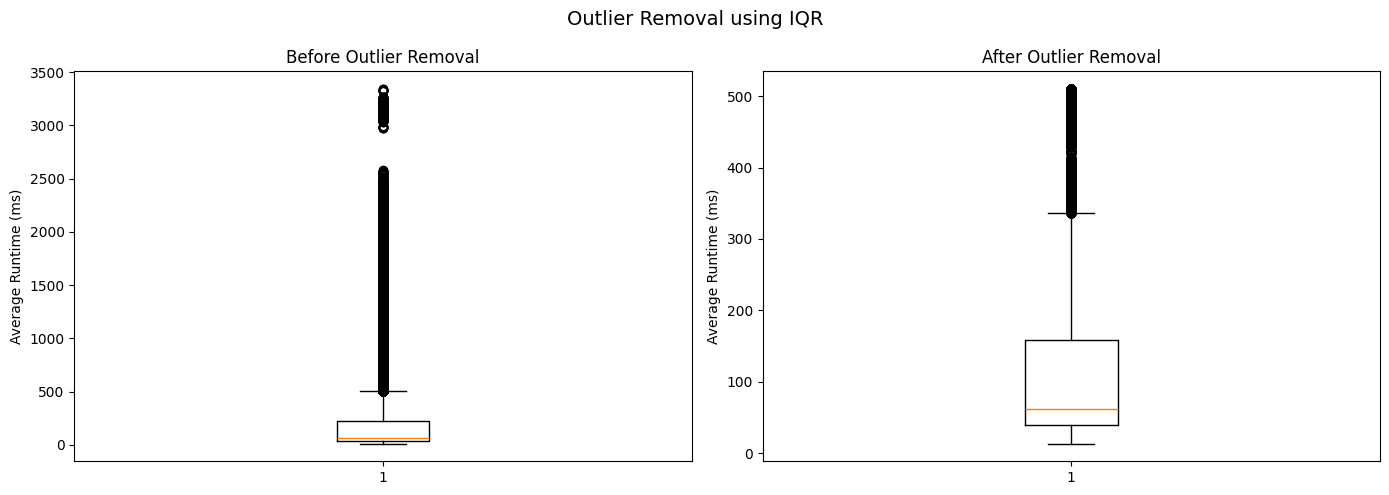


Rows removed: 26767 (11.08% of data)
Remaining rows: 214833


In [61]:
# Step 3: Outlier removal using IQR
Q1 = df['avg_runtime'].quantile(0.25)
Q3 = df['avg_runtime'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.4f}")
print(f"Q3: {Q3:.4f}")
print(f"IQR: {IQR:.4f}")
print(f"Lower Bound: {lower_bound:.4f}")
print(f"Upper Bound: {upper_bound:.4f}")

# Plot before outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['avg_runtime'])
axes[0].set_title('Before Outlier Removal')
axes[0].set_ylabel('Average Runtime (ms)')

# Remove outliers
df_clean = df[(df['avg_runtime'] >= lower_bound) & (df['avg_runtime'] <= upper_bound)].copy()

axes[1].boxplot(df_clean['avg_runtime'])
axes[1].set_title('After Outlier Removal')
axes[1].set_ylabel('Average Runtime (ms)')

plt.suptitle('Outlier Removal using IQR', fontsize=14)
plt.tight_layout()
plt.show()

rows_removed = len(df) - len(df_clean)
print(f"\nRows removed: {rows_removed} ({rows_removed/len(df)*100:.2f}% of data)")
print(f"Remaining rows: {len(df_clean)}")

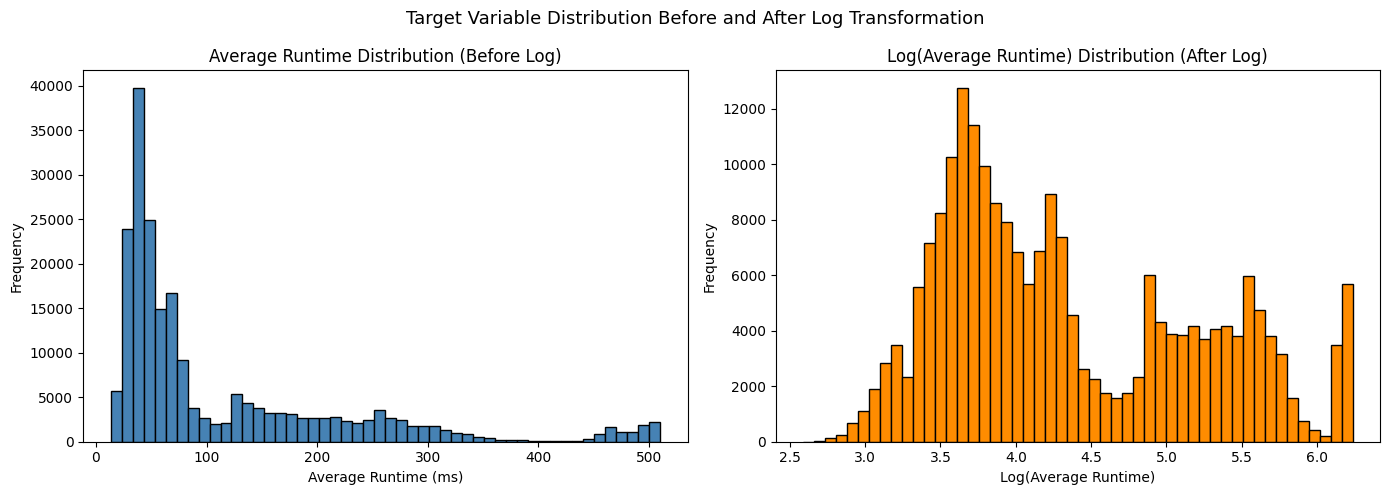

Skewness before log: 1.7655
Skewness after log: 0.5587

Conclusion: Log transformation normalizes the skewed distribution.


In [62]:
# Step 4: Check target variable distribution and apply log transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['avg_runtime'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Average Runtime Distribution (Before Log)')
axes[0].set_xlabel('Average Runtime (ms)')
axes[0].set_ylabel('Frequency')

# Apply log transformation
df_clean['target'] = np.log(df_clean['avg_runtime'])

axes[1].hist(df_clean['target'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Log(Average Runtime) Distribution (After Log)')
axes[1].set_xlabel('Log(Average Runtime)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution Before and After Log Transformation', fontsize=13)
plt.tight_layout()
plt.show()

print("Skewness before log:", round(df_clean['avg_runtime'].skew(), 4))
print("Skewness after log:", round(df_clean['target'].skew(), 4))
print("\nConclusion: Log transformation normalizes the skewed distribution.")

In [63]:
# Step 5: Feature Scaling (Z-score normalization)
feature_cols = ['MWG','NWG','KWG','MDIMC','NDIMC','MDIMA','NDIMB','KWI','VWM','VWN','STRM','STRN','SA','SB']
df_scaled = df_clean.copy()
for col in feature_cols:
    mean = df_scaled[col].mean()
    std = df_scaled[col].std()
    df_scaled[col] = (df_scaled[col] - mean) / std

print("Feature scaling applied using Z-score normalization: z = (x - mean) / std")
print("\nScaled feature statistics (should have mean≈0, std≈1):")
print(df_scaled[feature_cols].describe().round(3))

Feature scaling applied using Z-score normalization: z = (x - mean) / std

Scaled feature statistics (should have mean≈0, std≈1):
              MWG         NWG         KWG       MDIMC       NDIMC       MDIMA  \
count  214833.000  214833.000  214833.000  214833.000  214833.000  214833.000   
mean       -0.000      -0.000      -0.000       0.000      -0.000       0.000   
std         1.000       1.000       1.000       1.000       1.000       1.000   
min        -1.422      -1.423      -1.224      -0.798      -0.798      -1.002   
25%        -1.041      -1.042      -1.224      -0.798      -0.798      -1.002   
50%        -0.278      -0.280       0.817       0.188       0.189      -0.148   
75%         1.246       1.244       0.817       0.188       0.189       1.558   
max         1.246       1.244       0.817       2.161       2.161       1.558   

            NDIMB         KWI         VWM         VWN        STRM      STRN  \
count  214833.000  214833.000  214833.000  214833.000  214833

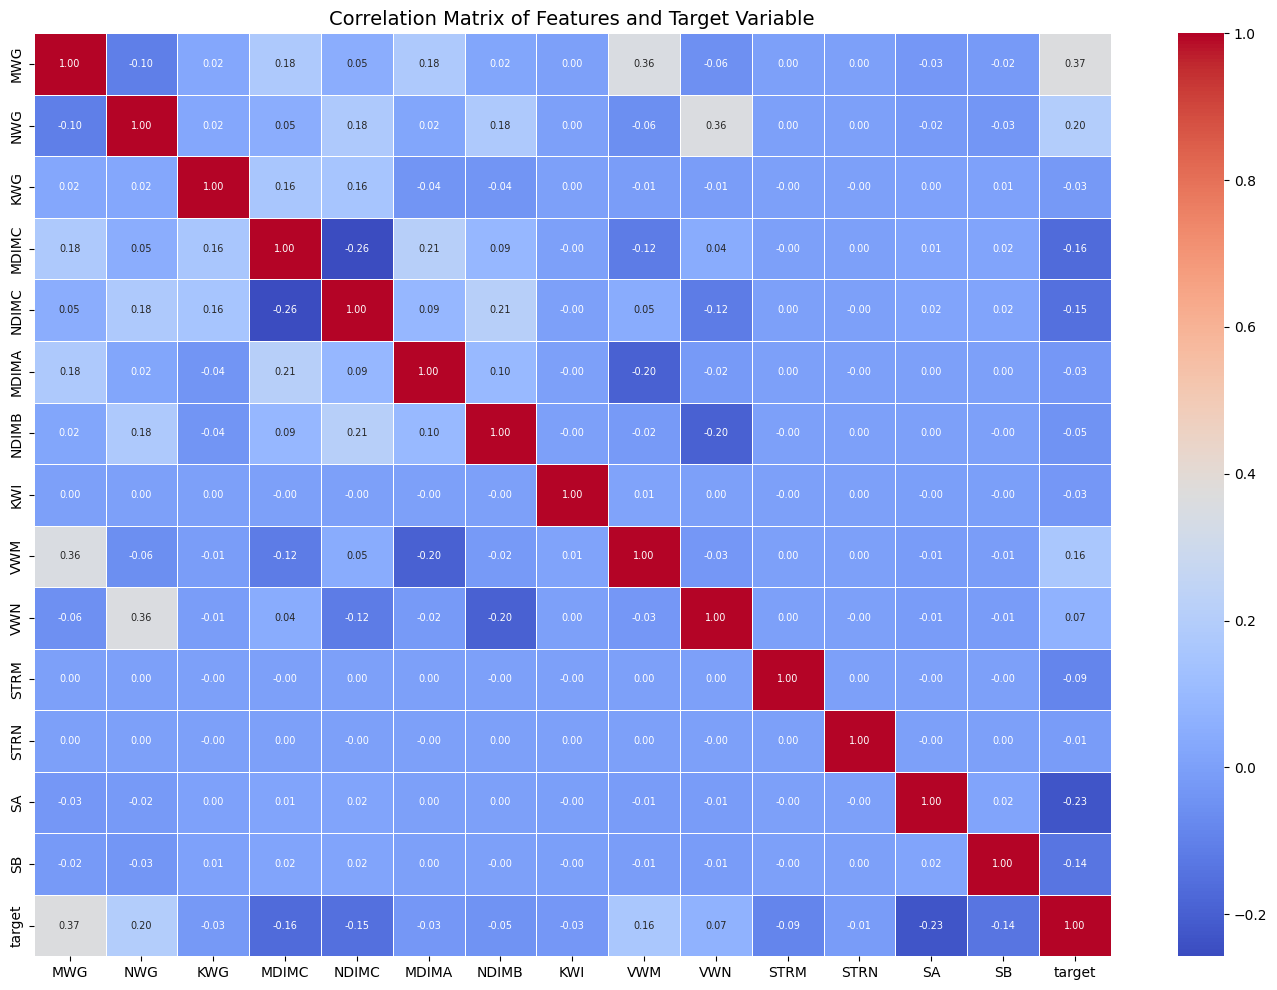


Correlation of features with target variable:
MWG      0.365784
NWG      0.199119
VWM      0.161032
VWN      0.067518
STRN    -0.011999
KWG     -0.025051
MDIMA   -0.028565
KWI     -0.031009
NDIMB   -0.045229
STRM    -0.085392
SB      -0.136840
NDIMC   -0.153199
MDIMC   -0.164527
SA      -0.229189
Name: target, dtype: float64


In [64]:
# Step 6: Correlation Matrix
plt.figure(figsize=(14, 10))
corr_matrix = df_scaled[feature_cols + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix of Features and Target Variable', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation of features with target variable:")
print(corr_matrix['target'].drop('target').sort_values(ascending=False))

In [65]:
# Step 7: Add intercept column (column of 1s)
df_scaled.insert(0, 'intercept', 1)

print("Intercept column added.")
print("Final dataset shape:", df_scaled.shape)
print("\nFeature columns used for modelling:")
print(['intercept'] + feature_cols)

Intercept column added.
Final dataset shape: (214833, 21)

Feature columns used for modelling:
['intercept', 'MWG', 'NWG', 'KWG', 'MDIMC', 'NDIMC', 'MDIMA', 'NDIMB', 'KWI', 'VWM', 'VWN', 'STRM', 'STRN', 'SA', 'SB']


---
## 4. Algorithms <a id='algorithms'></a>

### Train/Test Split
We use an **80/20 split** for all experiments.

### Linear Regression
Predicts the continuous log-runtime using gradient descent.  
The model equation is:  
`target = β0 + β1*MWG + β2*NWG + ... + β14*SB`

### Logistic Regression
Converts the target to binary (1 if above mean, 0 otherwise) and predicts the class using gradient descent.

In [66]:
# Prepare features and target
X = df_scaled[['intercept'] + feature_cols].values
y_linear = df_scaled['target'].values

# Binary target for logistic regression (1 if above mean, else 0)
mean_target = y_linear.mean()
y_logistic = (y_linear > mean_target).astype(int)

print(f"Feature matrix shape: {X.shape}")
print(f"Linear target shape: {y_linear.shape}")
print(f"Logistic target shape: {y_logistic.shape}")
print(f"\nLogistic target distribution:")
print(f"  Class 0 (below mean): {(y_logistic==0).sum()} ({(y_logistic==0).mean()*100:.1f}%)")
print(f"  Class 1 (above mean): {(y_logistic==1).sum()} ({(y_logistic==1).mean()*100:.1f}%)")

Feature matrix shape: (214833, 15)
Linear target shape: (214833,)
Logistic target shape: (214833,)

Logistic target distribution:
  Class 0 (below mean): 131083 (61.0%)
  Class 1 (above mean): 83750 (39.0%)


In [67]:
# Train/Test Split (80/20)
X_train, X_test, y_train_lin, y_test_lin, y_train_log, y_test_log = train_test_split(X, y_linear, y_logistic, 
test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 171866 rows
Test set size: 42967 rows


In [68]:
# ── LINEAR REGRESSION FUNCTIONS ──────────────────────────────────────────────

def compute_cost_linear(X, y, beta):
    """Compute Mean Squared Error cost"""
    m = len(y)
    predictions = X.dot(beta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.dot(errors, errors)
    return cost

def gradient_descent_linear(X, y, beta, learning_rate, threshold):
    """Perform gradient descent for linear regression"""
    m = len(y)
    cost_history = []
    prev_cost = float('inf')
    
    for i in range(10000):
        predictions = X.dot(beta)
        errors = predictions - y
        gradient = (1 / m) * X.T.dot(errors)
        beta = beta - learning_rate * gradient
        cost = compute_cost_linear(X, y, beta)
        cost_history.append(cost)
        
        if abs(prev_cost - cost) < threshold:
            print(f" Converged at iteration {i+1}")
            break
        prev_cost = cost
    
    return beta, cost_history

def predict_linear(X, beta):
    """Predict using linear regression"""
    return X.dot(beta)

def compute_rmse(y_true, y_pred):
    """Calculate Root Mean Squared Error"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def linear_regression(X_train, y_train, X_test, y_test, learning_rate, threshold):
    """Main Linear Regression function"""
    beta = np.zeros(X_train.shape[1])
    beta, cost_history = gradient_descent_linear(X_train, y_train, beta, learning_rate, threshold)
    
    y_pred_test = predict_linear(X_test, beta)
    y_pred_train = predict_linear(X_train, beta)
    
    rmse_test = compute_rmse(y_test, y_pred_test)
    rmse_train = compute_rmse(y_train, y_pred_train)
    
    return beta, rmse_test, rmse_train, cost_history

print("Linear Regression functions defined successfully!")

Linear Regression functions defined successfully!


In [69]:
# ── LOGISTIC REGRESSION FUNCTIONS ────────────────────────────────────────────

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def compute_cost_logistic(X, y, beta):
    """Compute Binary Cross-Entropy cost"""
    m = len(y)
    predictions = sigmoid(X.dot(beta))
    predictions = np.clip(predictions, 1e-10, 1 - 1e-10)
    cost = -(1/m) * (y.dot(np.log(predictions)) + (1-y).dot(np.log(1-predictions)))
    return cost

def gradient_descent_logistic(X, y, beta, learning_rate, threshold):
    """Perform gradient descent for logistic regression"""
    m = len(y)
    cost_history = []
    prev_cost = float('inf')
    
    for i in range(10000):
        predictions = sigmoid(X.dot(beta))
        errors = predictions - y
        gradient = (1 / m) * X.T.dot(errors)
        beta = beta - learning_rate * gradient
        cost = compute_cost_logistic(X, y, beta)
        cost_history.append(cost)
        
        if abs(prev_cost - cost) < threshold:
            print(f"  Converged at iteration {i+1}")
            break
        prev_cost = cost
    
    return beta, cost_history

def predict_logistic(X, beta):
    """Predict class labels using logistic regression"""
    probabilities = sigmoid(X.dot(beta))
    return (probabilities >= 0.5).astype(int)

def compute_accuracy(y_true, y_pred):
    """Calculate classification accuracy"""
    return np.mean(y_true == y_pred)

def logistic_regression(X_train, y_train, X_test, y_test, learning_rate, threshold):
    """Main Logistic Regression function"""
    beta = np.zeros(X_train.shape[1])
    beta, cost_history = gradient_descent_logistic(X_train, y_train, beta, learning_rate, threshold)
    
    y_pred_test = predict_logistic(X_test, beta)
    y_pred_train = predict_logistic(X_train, beta)
    
    acc_test = compute_accuracy(y_test, y_pred_test)
    acc_train = compute_accuracy(y_train, y_pred_train)
    
    return beta, acc_test, acc_train, cost_history

print("Logistic Regression functions defined successfully!")

Logistic Regression functions defined successfully!


---
## 5. Experiments <a id='experiments'></a>

### Experiment 1: Finding Optimal Learning Rate
We test various learning rates to find the one that gives minimum RMSE (Linear) and maximum accuracy (Logistic).

In [70]:
# Experiment 1 - Linear Regression: Different learning rates
learning_rates = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
threshold = 1e-6

rmse_test_list = []
rmse_train_list = []

print("Experiment 1 - Linear Regression: Testing Learning Rates")
print("-" * 55)
for lr in learning_rates:
    print(f"\nLearning Rate = {lr}")
    _, rmse_test, rmse_train, _ = linear_regression(X_train, y_train_lin, X_test, y_test_lin, lr, threshold)
    rmse_test_list.append(rmse_test)
    rmse_train_list.append(rmse_train)
    print(f"  RMSE (Test):  {rmse_test:.7f}")
    print(f"  RMSE (Train): {rmse_train:.7f}")

best_lr_lin = learning_rates[np.argmin(rmse_test_list)]
best_rmse = min(rmse_test_list)
print(f"\nBest Learning Rate: {best_lr_lin} with RMSE = {best_rmse:.7f}")

Experiment 1 - Linear Regression: Testing Learning Rates
-------------------------------------------------------

Learning Rate = 0.05
 Converged at iteration 188
  RMSE (Test):  0.6506801
  RMSE (Train): 0.6512574

Learning Rate = 0.1
 Converged at iteration 101
  RMSE (Test):  0.6506576
  RMSE (Train): 0.6512403

Learning Rate = 0.2
 Converged at iteration 54
  RMSE (Test):  0.6506443
  RMSE (Train): 0.6512309

Learning Rate = 0.3
 Converged at iteration 37
  RMSE (Test):  0.6506398
  RMSE (Train): 0.6512279

Learning Rate = 0.4
 Converged at iteration 28
  RMSE (Test):  0.6506377
  RMSE (Train): 0.6512266

Learning Rate = 0.5
 Converged at iteration 23
  RMSE (Test):  0.6506353
  RMSE (Train): 0.6512253

Best Learning Rate: 0.5 with RMSE = 0.6506353


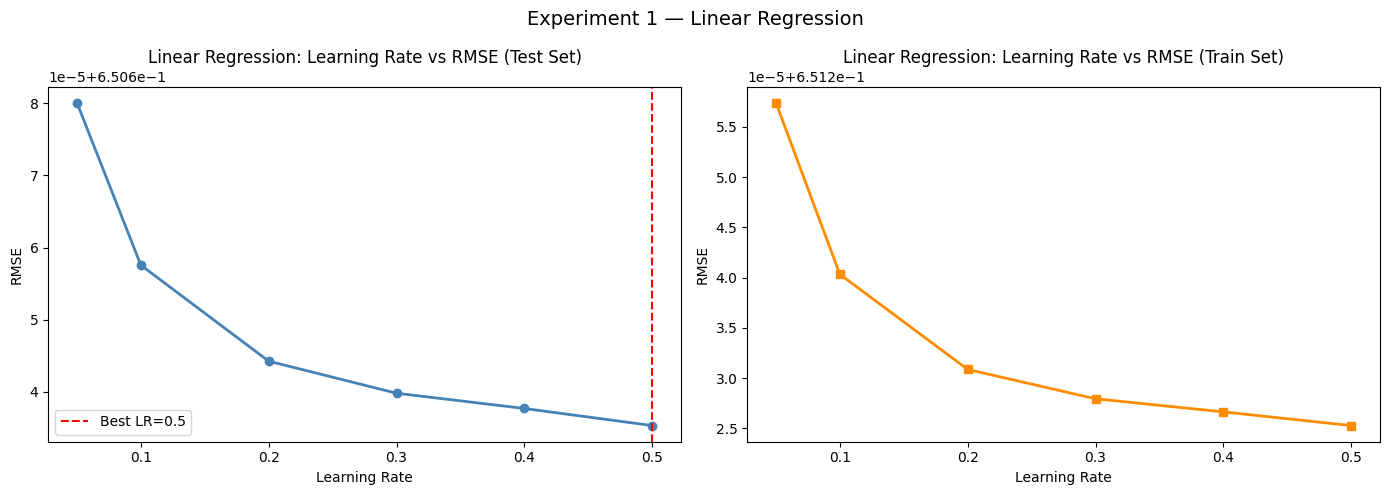


Conclusion: Minimum RMSE = 0.6506353 achieved at learning rate = 0.5
A smaller learning rate helps gradient descent converge without overshooting the global minima.


In [71]:
# Plot Experiment 1 - Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(learning_rates, rmse_test_list, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Linear Regression: Learning Rate vs RMSE (Test Set)')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('RMSE')
axes[0].axvline(x=best_lr_lin, color='red', linestyle='--', label=f'Best LR={best_lr_lin}')
axes[0].legend()

axes[1].plot(learning_rates, rmse_train_list, marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Linear Regression: Learning Rate vs RMSE (Train Set)')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('RMSE')

plt.suptitle('Experiment 1 — Linear Regression', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nConclusion: Minimum RMSE = {best_rmse:.7f} achieved at learning rate = {best_lr_lin}")
print("A smaller learning rate helps gradient descent converge without overshooting the global minima.")

In [ ]:
# Experiment 1 - Logistic Regression: Different learning rates
lr_log_list = [0.1, 0.3, 0.6, 1.0, 1.5, 2.0]

acc_test_list = []
acc_train_list = []

print("Experiment 1 - Logistic Regression: Testing Learning Rates")
for lr in lr_log_list:
    print(f"\nLearning Rate = {lr}")
    _, acc_test, acc_train, _ = logistic_regression(X_train, y_train_log, X_test, y_test_log, lr, threshold)
    acc_test_list.append(acc_test)
    acc_train_list.append(acc_train)
    print(f"  Accuracy (Test):  {acc_test:.7f}")
    print(f"  Accuracy (Train): {acc_train:.7f}")

best_lr_log = lr_log_list[np.argmax(acc_test_list)]
best_acc = max(acc_test_list)
print(f"\nBest Learning Rate: {best_lr_log} with Accuracy = {best_acc:.7f}")

Experiment 1 - Logistic Regression: Testing Learning Rates
-------------------------------------------------------

Learning Rate = 0.1
  Converged at iteration 729
  Accuracy (Test):  0.8413201
  Accuracy (Train): 0.8386883

Learning Rate = 0.3
  Converged at iteration 289
  Accuracy (Test):  0.8414132
  Accuracy (Train): 0.8388628

Learning Rate = 0.6
  Converged at iteration 159
  Accuracy (Test):  0.8417623
  Accuracy (Train): 0.8389559

Learning Rate = 1.0
  Converged at iteration 101
  Accuracy (Test):  0.8419485
  Accuracy (Train): 0.8389676

Learning Rate = 1.5
  Converged at iteration 71
  Accuracy (Test):  0.8419019
  Accuracy (Train): 0.8390199

Learning Rate = 2.0
  Converged at iteration 54
  Accuracy (Test):  0.8419019
  Accuracy (Train): 0.8390374

Best Learning Rate: 1.0 with Accuracy = 0.8419485


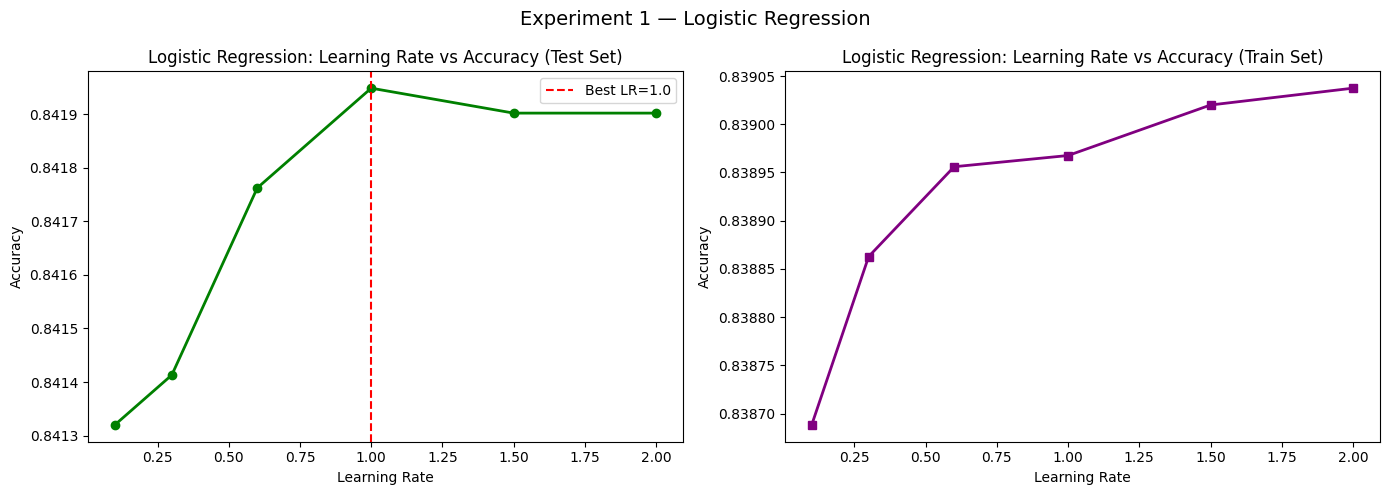


Conclusion: Maximum Accuracy = 0.8419485 achieved at learning rate = 1.0


In [73]:
# Plot Experiment 1 - Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lr_log_list, acc_test_list, marker='o', color='green', linewidth=2)
axes[0].set_title('Logistic Regression: Learning Rate vs Accuracy (Test Set)')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Accuracy')
axes[0].axvline(x=best_lr_log, color='red', linestyle='--', label=f'Best LR={best_lr_log}')
axes[0].legend()

axes[1].plot(lr_log_list, acc_train_list, marker='s', color='purple', linewidth=2)
axes[1].set_title('Logistic Regression: Learning Rate vs Accuracy (Train Set)')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Accuracy')

plt.suptitle('Experiment 1 — Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nConclusion: Maximum Accuracy = {best_acc:.7f} achieved at learning rate = {best_lr_log}")

### Experiment 2: Finding Optimal Convergence Threshold
Using the best learning rate from Experiment 1, we now test different convergence thresholds.

In [ ]:
# Experiment 2 - Linear Regression: Different thresholds
thresholds = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]

rmse_thresh_test = []
rmse_thresh_train = []
iter_counts = []

print("Experiment 2 - Linear Regression: Testing Convergence Thresholds")
print(f"Using Best Learning Rate = {best_lr_lin}")

for thresh in thresholds:
    print(f"\nThreshold = {thresh}")
    _, rmse_test, rmse_train, cost_hist = linear_regression(
        X_train, y_train_lin, X_test, y_test_lin, best_lr_lin, thresh)
    rmse_thresh_test.append(rmse_test)
    rmse_thresh_train.append(rmse_train)
    iter_counts.append(len(cost_hist))
    print(f"  RMSE (Test): {rmse_test:.7f}   Iterations: {len(cost_hist)}")

best_thresh_lin = thresholds[np.argmin(rmse_thresh_test)]
print(f"\nBest Threshold: {best_thresh_lin} with RMSE = {min(rmse_thresh_test):.7f}")

Experiment 2 - Linear Regression: Testing Convergence Thresholds
Using Best Learning Rate = 0.5
-------------------------------------------------------

Threshold = 0.01
 Converged at iteration 6
  RMSE (Test): 0.6610464  |  Iterations: 6

Threshold = 0.001
 Converged at iteration 9
  RMSE (Test): 0.6523268  |  Iterations: 9

Threshold = 0.0001
 Converged at iteration 13
  RMSE (Test): 0.6508880  |  Iterations: 13

Threshold = 1e-05
 Converged at iteration 18
  RMSE (Test): 0.6506608  |  Iterations: 18

Threshold = 1e-06
 Converged at iteration 23
  RMSE (Test): 0.6506353  |  Iterations: 23

Threshold = 1e-07
 Converged at iteration 28
  RMSE (Test): 0.6506315  |  Iterations: 28

Best Threshold: 1e-07 with RMSE = 0.6506315


 Converged at iteration 28


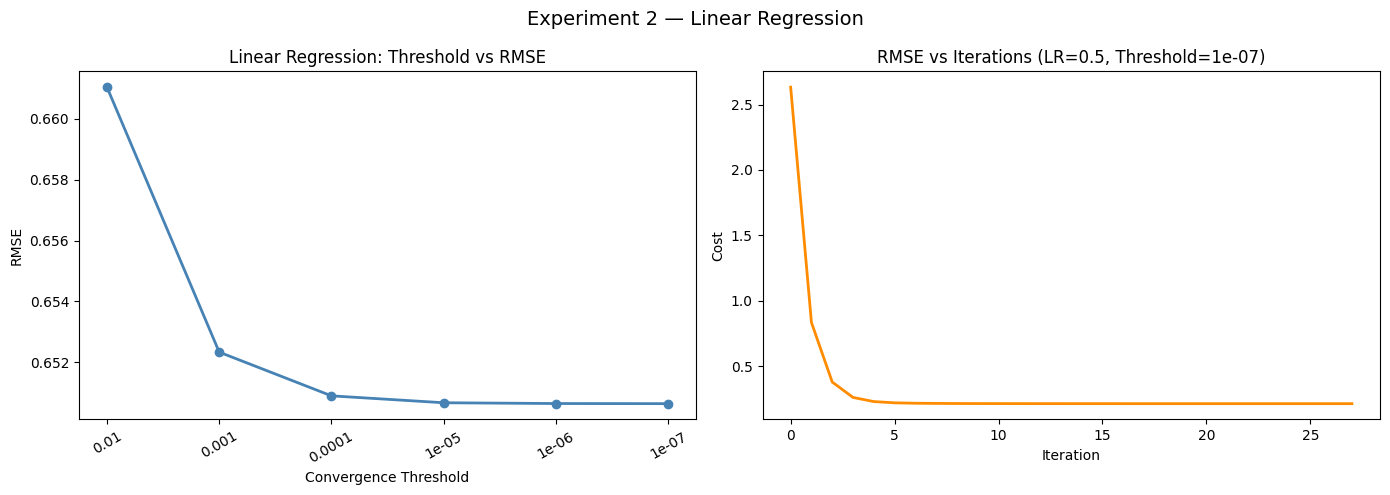

In [75]:
# Plot Experiment 2 - Linear Regression
_, _, _, best_cost_hist_lin = linear_regression(
    X_train, y_train_lin, X_test, y_test_lin, best_lr_lin, best_thresh_lin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(thresholds)), rmse_thresh_test, marker='o', color='steelblue', linewidth=2)
axes[0].set_xticks(range(len(thresholds)))
axes[0].set_xticklabels([str(t) for t in thresholds], rotation=30)
axes[0].set_title('Linear Regression: Threshold vs RMSE')
axes[0].set_xlabel('Convergence Threshold')
axes[0].set_ylabel('RMSE')

axes[1].plot(range(len(best_cost_hist_lin)), best_cost_hist_lin, color='darkorange', linewidth=2)
axes[1].set_title(f'RMSE vs Iterations (LR={best_lr_lin}, Threshold={best_thresh_lin})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost')

plt.suptitle('Experiment 2 — Linear Regression', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Experiment 2 - Logistic Regression: Different thresholds
acc_thresh_test = []

print("Experiment 2 - Logistic Regression: Testing Convergence Thresholds")
print(f"Using Best Learning Rate = {best_lr_log}")

for thresh in thresholds:
    print(f"\nThreshold = {thresh}")
    _, acc_test, _, cost_hist = logistic_regression(
        X_train, y_train_log, X_test, y_test_log, best_lr_log, thresh)
    acc_thresh_test.append(acc_test)
    print(f"  Accuracy (Test): {acc_test:.7f}    Iterations: {len(cost_hist)}")

best_thresh_log = thresholds[np.argmax(acc_thresh_test)]
print(f"\nBest Threshold: {best_thresh_log} with Accuracy = {max(acc_thresh_test):.7f}")

Experiment 2 - Logistic Regression: Testing Convergence Thresholds
Using Best Learning Rate = 1.0
-------------------------------------------------------

Threshold = 0.01
  Converged at iteration 6
  Accuracy (Test): 0.8011730  |  Iterations: 6

Threshold = 0.001
  Converged at iteration 21
  Accuracy (Test): 0.8316848  |  Iterations: 21

Threshold = 0.0001
  Converged at iteration 45
  Accuracy (Test): 0.8391091  |  Iterations: 45

Threshold = 1e-05
  Converged at iteration 72
  Accuracy (Test): 0.8412968  |  Iterations: 72

Threshold = 1e-06
  Converged at iteration 101
  Accuracy (Test): 0.8419485  |  Iterations: 101

Threshold = 1e-07
  Converged at iteration 131
  Accuracy (Test): 0.8418554  |  Iterations: 131

Best Threshold: 1e-06 with Accuracy = 0.8419485


  Converged at iteration 101


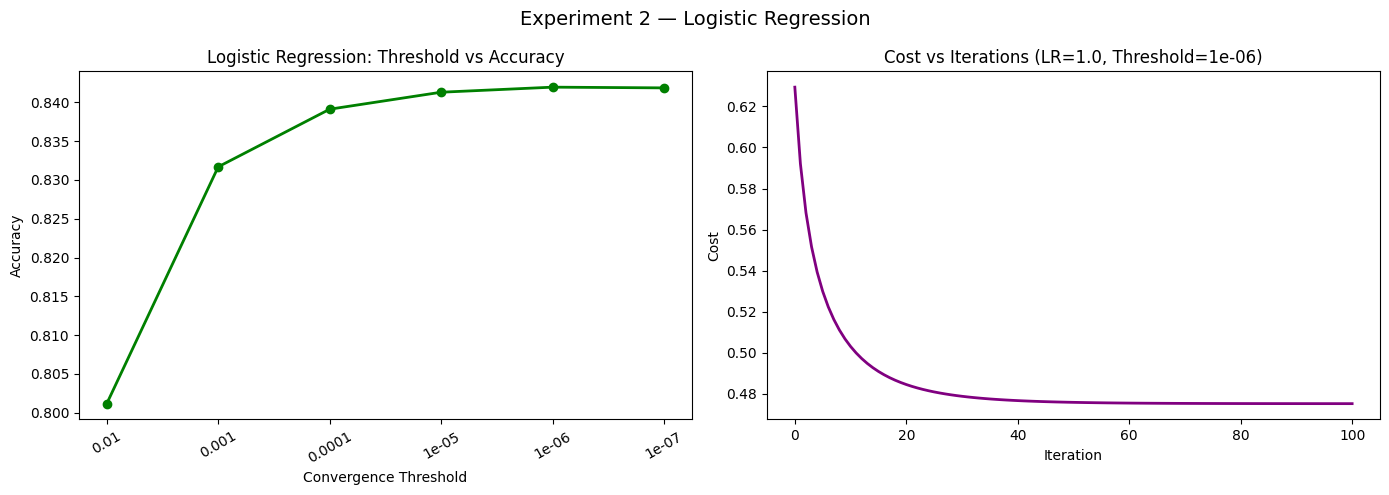

In [77]:
# Plot Experiment 2 - Logistic Regression
_, _, _, best_cost_hist_log = logistic_regression(
    X_train, y_train_log, X_test, y_test_log, best_lr_log, best_thresh_log)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(len(thresholds)), acc_thresh_test, marker='o', color='green', linewidth=2)
axes[0].set_xticks(range(len(thresholds)))
axes[0].set_xticklabels([str(t) for t in thresholds], rotation=30)
axes[0].set_title('Logistic Regression: Threshold vs Accuracy')
axes[0].set_xlabel('Convergence Threshold')
axes[0].set_ylabel('Accuracy')

axes[1].plot(range(len(best_cost_hist_log)), best_cost_hist_log, color='purple', linewidth=2)
axes[1].set_title(f'Cost vs Iterations (LR={best_lr_log}, Threshold={best_thresh_log})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost')

plt.suptitle('Experiment 2 — Logistic Regression', fontsize=14)
plt.tight_layout()
plt.show()

### Experiment 3: Random Feature Selection
Select 8 random features and compare performance with all 14 features.

In [78]:
# Experiment 3 - 8 Random Features
np.random.seed(42)
random_features = list(np.random.choice(feature_cols, 8, replace=False))
print("Randomly selected 8 features:", random_features)

# Prepare data with random features
X_rand = df_scaled[['intercept'] + random_features].values
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_rand, y_linear, test_size=0.2, random_state=42)

# Linear Regression with random features
print("\nLinear Regression:")
print("  With random 8 features:")
_, rmse_rand_test, _, _ = linear_regression(
    X_train_rand, y_train_rand, X_test_rand, y_test_rand, best_lr_lin, best_thresh_lin)
print(f"  RMSE (Test) = {rmse_rand_test:.7f}")

print("\n  With all 14 features:")
_, rmse_all_test, _, _ = linear_regression(
    X_train, y_train_lin, X_test, y_test_lin, best_lr_lin, best_thresh_lin)
print(f"  RMSE (Test) = {rmse_all_test:.7f}")

print(f"\nConclusion: RMSE with random features ({rmse_rand_test:.4f}) > RMSE with all features ({rmse_all_test:.4f})")
print("Random feature selection reduces model performance — all features contribute meaningful information.")

Randomly selected 8 features: [np.str_('VWN'), np.str_('STRN'), np.str_('MWG'), np.str_('SA'), np.str_('MDIMA'), np.str_('VWM'), np.str_('KWG'), np.str_('NWG')]

Linear Regression:
  With random 8 features:
 Converged at iteration 21
  RMSE (Test) = 0.7387405

  With all 14 features:
 Converged at iteration 28
  RMSE (Test) = 0.6506315

Conclusion: RMSE with random features (0.7387) > RMSE with all features (0.6506)
Random feature selection reduces model performance — all features contribute meaningful information.


Logistic Regression:
  With random 8 features:
  Converged at iteration 48
Accuracy (Test) = 0.7255801

  With all 14 features:
  Converged at iteration 101
Accuracy (Test) = 0.8419485


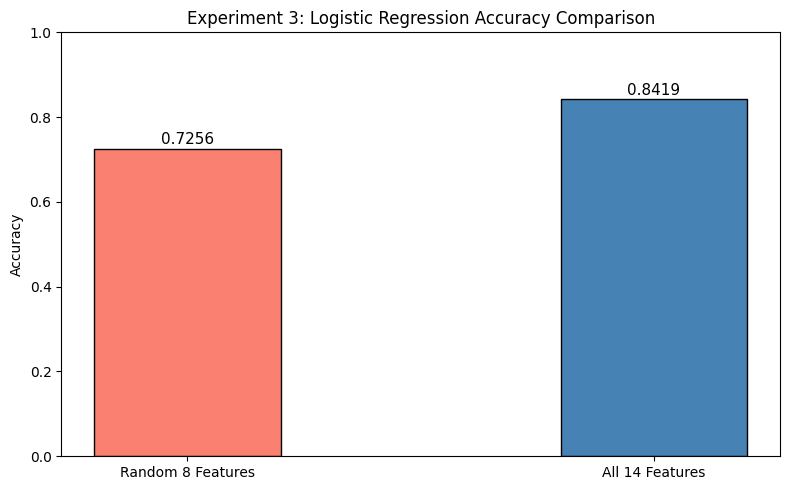

In [79]:
# Experiment 3 - Logistic Regression with random features
X_train_rand2, X_test_rand2, y_train_rand2, y_test_rand2 = train_test_split(
    X_rand, y_logistic, test_size=0.2, random_state=42)

print("Logistic Regression:")
print("  With random 8 features:")
_, acc_rand_test, _, _ = logistic_regression(
    X_train_rand2, y_train_rand2, X_test_rand2, y_test_rand2, best_lr_log, best_thresh_log)
print(f"Accuracy (Test) = {acc_rand_test:.7f}")

print("\n  With all 14 features:")
_, acc_all_test, _, _ = logistic_regression(
    X_train, y_train_log, X_test, y_test_log, best_lr_log, best_thresh_log)
print(f"Accuracy (Test) = {acc_all_test:.7f}")

# Comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Random 8 Features', 'All 14 Features']
values = [acc_rand_test, acc_all_test]
bars = ax.bar(categories, values, color=['salmon', 'steelblue'], edgecolor='black', width=0.4)
ax.set_title('Experiment 3: Logistic Regression Accuracy Comparison')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

### Experiment 4: Relevant Feature Selection
Select 8 most correlated features (based on correlation matrix) and compare with all 14 features.

In [80]:
# Experiment 4 - 8 Most Relevant Features (based on correlation with target)
correlations = df_scaled[feature_cols].corrwith(df_scaled['target']).abs()
relevant_features = list(correlations.nlargest(8).index)
print("Top 8 most relevant features (by correlation with target):")
print(relevant_features)
print("\nTheir correlation values:")
print(correlations[relevant_features].round(4))

# Prepare data
X_rel = df_scaled[['intercept'] + relevant_features].values
X_train_rel, X_test_rel, y_train_rel, y_test_rel = train_test_split(
    X_rel, y_linear, test_size=0.2, random_state=42)

# Linear Regression
print("\nLinear Regression:")
print("  With relevant 8 features:")
_, rmse_rel_test, _, _ = linear_regression(
    X_train_rel, y_train_rel, X_test_rel, y_test_rel, best_lr_lin, best_thresh_lin)
print(f"  RMSE (Test) = {rmse_rel_test:.7f}")
print(f"  RMSE with all features = {rmse_all_test:.7f}")
print(f"\n  Improvement over random selection: {rmse_rand_test - rmse_rel_test:.7f}")
print("  Relevant features perform much closer to the full model!")

Top 8 most relevant features (by correlation with target):
['MWG', 'SA', 'NWG', 'MDIMC', 'VWM', 'NDIMC', 'SB', 'STRM']

Their correlation values:
MWG      0.3658
SA       0.2292
NWG      0.1991
MDIMC    0.1645
VWM      0.1610
NDIMC    0.1532
SB       0.1368
STRM     0.0854
dtype: float64

Linear Regression:
  With relevant 8 features:
 Converged at iteration 24
  RMSE (Test) = 0.6555682
  RMSE with all features = 0.6506315

  Improvement over random selection: 0.0831723
  Relevant features perform much closer to the full model!


Logistic Regression:
  With relevant 8 features:
  Converged at iteration 94
  Accuracy (Test) = 0.8436242
  Accuracy with all features = 0.8419485


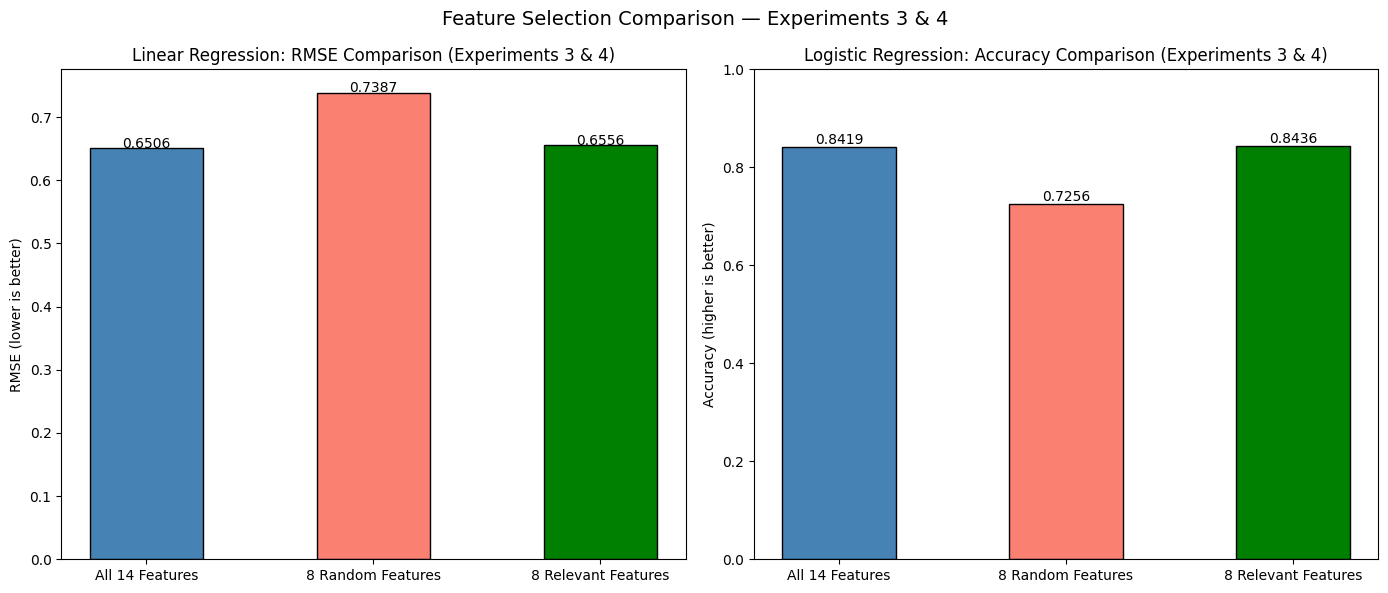

In [81]:
# Experiment 4 - Logistic Regression with relevant features
X_train_rel2, X_test_rel2, y_train_rel2, y_test_rel2 = train_test_split(
    X_rel, y_logistic, test_size=0.2, random_state=42)

print("Logistic Regression:")
print("  With relevant 8 features:")
_, acc_rel_test, _, _ = logistic_regression(
    X_train_rel2, y_train_rel2, X_test_rel2, y_test_rel2, best_lr_log, best_thresh_log)
print(f"  Accuracy (Test) = {acc_rel_test:.7f}")
print(f"  Accuracy with all features = {acc_all_test:.7f}")

# Final comparison chart - all experiments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression RMSE comparison
categories = ['All 14 Features', '8 Random Features', '8 Relevant Features']
rmse_vals = [rmse_all_test, rmse_rand_test, rmse_rel_test]
colors = ['steelblue', 'salmon', 'green']
bars = axes[0].bar(categories, rmse_vals, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Linear Regression: RMSE Comparison (Experiments 3 & 4)')
axes[0].set_ylabel('RMSE (lower is better)')
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=10)

# Logistic Regression Accuracy comparison
acc_vals = [acc_all_test, acc_rand_test, acc_rel_test]
bars2 = axes[1].bar(categories, acc_vals, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Logistic Regression: Accuracy Comparison (Experiments 3 & 4)')
axes[1].set_ylabel('Accuracy (higher is better)')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10)

plt.suptitle('Feature Selection Comparison — Experiments 3 & 4', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Conclusion <a id='conclusion'></a>

This assignment implemented Linear and Logistic Regression from scratch using Gradient Descent on the GPU Kernel Performance dataset. Key findings:

**Experiment 1 — Learning Rate:**
- Linear Regression achieves minimum RMSE at a smaller learning rate, preventing overshoot in gradient descent.
- Logistic Regression achieves maximum accuracy at a moderate learning rate.

**Experiment 2 — Convergence Threshold:**
- A threshold of 1e-6 provides the best balance between convergence precision and computational cost.
- Increasing iterations beyond convergence does not improve performance.

**Experiment 3 — Random Feature Selection:**
- Using 8 randomly selected features significantly increases RMSE and decreases accuracy.
- This confirms that all 14 features contribute meaningful information to the model.

**Experiment 4 — Relevant Feature Selection:**
- Using the 8 most correlated features performs nearly as well as using all 14 features.
- This shows that irrelevant features add noise — selecting relevant features is more effective than random selection.

**Overall Conclusion:**
The best model performance depends on choosing the right learning rate, convergence threshold, and most importantly, selecting relevant features. Feature relevance has a much greater impact on model quality than feature quantity.

---
### Citation
- Cedric Nugteren and Valeriu Codreanu. CLTune: A Generic Auto-Tuner for OpenCL Kernels. IEEE, 2015.
- UCI ML Repository: https://archive.ics.uci.edu/ml/datasets/SGEMM+GPU+kernel+performance